# mmraz-qwen3-probe-variations-question-options-answer-vast-plots

Small plotting notebook for the Qwen3 4B probe-variation Vast run.

It:
- finds the latest compatible Qwen3 probe-training run by default,
- loads its saved metrics / summary / metadata,
- reproduces the same plot structure used in `mmraz-probe-variations-question-options-answer.ipynb`, and
- saves the replotted figures under a `replots_from_notebook/` subdirectory inside that run folder.


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

plt.rcParams['figure.dpi'] = 130
plt.rcParams['lines.markersize'] = 5

REQUIRED_ARTIFACT_FORMAT_VERSION = 4
RUN_DIR_OVERRIDE = globals().get('RUN_DIR_OVERRIDE', None)


def find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for _ in range(8):
        if (p / 'pyproject.toml').exists() and (p / 'notebooks').exists() and (p / 'results').exists():
            return p
        p = p.parent
    raise RuntimeError('Could not locate repo root from current working directory.')


def find_latest_run_dir(results_root: Path) -> Path:
    candidates = []
    for run_dir in sorted(results_root.iterdir()):
        if not run_dir.is_dir():
            continue
        metadata_candidates = sorted(run_dir.glob('qwen3_4b_question_options_answer_probe_metadata_*.json'))
        metrics_candidates = sorted(run_dir.glob('qwen3_4b_question_options_answer_probe_metrics_*.csv'))
        summary_candidates = sorted(run_dir.glob('qwen3_4b_question_options_answer_probe_summary_*.csv'))
        if not metadata_candidates or not metrics_candidates or not summary_candidates:
            continue
        metadata = json.loads(metadata_candidates[-1].read_text(encoding='utf-8'))
        if int(metadata.get('artifact_format_version', 0)) < REQUIRED_ARTIFACT_FORMAT_VERSION:
            continue
        if metadata.get('explicit_split_granularity') != 'pair':
            continue
        if not bool(metadata.get('probe_prompt_use_chat_template', metadata.get('use_chat_template', False))):
            continue
        if not bool(metadata.get('probe_prompt_disable_thinking_trace', metadata.get('disable_thinking_trace', False))):
            continue
        candidates.append(run_dir)
    if not candidates:
        raise FileNotFoundError(
            'Could not find any compatible Qwen3 probe-variation run directories under '
            f'{results_root} with artifact_format_version >= {REQUIRED_ARTIFACT_FORMAT_VERSION}. '
            'Rerun the updated training notebook first if needed.'
        )
    return candidates[-1]


ROOT = find_repo_root(Path.cwd())
RESULTS_ROOT = ROOT / 'results' / 'qwen_question_options_answer_probe_variations_vast'
RUN_DIR = Path(RUN_DIR_OVERRIDE).expanduser().resolve() if RUN_DIR_OVERRIDE is not None else find_latest_run_dir(RESULTS_ROOT)

metrics_path = sorted(RUN_DIR.glob('qwen3_4b_question_options_answer_probe_metrics_*.csv'))[-1]
summary_path = sorted(RUN_DIR.glob('qwen3_4b_question_options_answer_probe_summary_*.csv'))[-1]
metadata_path = sorted(RUN_DIR.glob('qwen3_4b_question_options_answer_probe_metadata_*.json'))[-1]
figure_index_candidates = sorted(RUN_DIR.glob('qwen3_4b_question_options_answer_probe_figures_*.csv'))
figure_index_path = figure_index_candidates[-1] if figure_index_candidates else None

metrics_df = pd.read_csv(metrics_path)
summary_df = pd.read_csv(summary_path)
metadata = json.loads(metadata_path.read_text(encoding='utf-8'))
saved_figure_index_df = pd.read_csv(figure_index_path) if figure_index_path is not None else pd.DataFrame()

artifact_df = pd.DataFrame([
    {'artifact': 'run_dir', 'path': str(RUN_DIR)},
    {'artifact': 'metrics_csv', 'path': str(metrics_path)},
    {'artifact': 'summary_csv', 'path': str(summary_path)},
    {'artifact': 'metadata_json', 'path': str(metadata_path)},
    {'artifact': 'saved_figure_index_csv', 'path': str(figure_index_path) if figure_index_path is not None else None},
])

display(artifact_df)
display(pd.DataFrame([metadata]).T)
display(summary_df)
display(metrics_df.head(20))
if len(saved_figure_index_df):
    display(saved_figure_index_df)


,artifact,path
0,run_dir,/Users/michalmraz/code/spar-ai/temporal-awaren...
1,metrics_csv,/Users/michalmraz/code/spar-ai/temporal-awaren...
2,summary_csv,/Users/michalmraz/code/spar-ai/temporal-awaren...
3,metadata_json,/Users/michalmraz/code/spar-ai/temporal-awaren...
4,saved_figure_index_csv,/Users/michalmraz/code/spar-ai/temporal-awaren...


,0
run_id,20260405-185421
model_name,Qwen/Qwen3-4B
selected_layers,"[10, 14, 18, 22, 26]"
feature_names,"[mean_answer_tokens, last_answer_token]"
train_regimes,"[explicit_train_only, explicit_train_plus_redt..."
train_regime_labels,"[explicit train only, + March 22, 2026 red-tea..."
explicit_split_random_state,42
explicit_split_granularity,pair
explicit_split_strategy,pair_level_80_20
explicit_train_pair_count,400


,train_dataset,feature_name,best_lr_explicit_layer,best_lr_explicit_acc,best_lr_implicit_layer,best_lr_implicit_acc,best_wlr_explicit_layer,best_wlr_explicit_acc,best_wlr_implicit_layer,best_wlr_implicit_acc,best_mm_explicit_layer,best_mm_explicit_acc,best_mm_implicit_layer,best_mm_implicit_acc,best_wmm_explicit_layer,best_wmm_explicit_acc,best_wmm_implicit_layer,best_wmm_implicit_acc
0,explicit_train_only,last_answer_token,18,1.000,22,0.948333,14,1.000,18,0.911667,14,0.960,14,0.780000,14,1.000,18,0.911667
1,explicit_train_only,mean_answer_tokens,18,0.995,18,0.923333,14,0.990,22,0.836667,10,0.980,26,0.883333,26,0.995,22,0.838333
2,explicit_train_plus_redteam_20260322-090107,last_answer_token,14,1.000,22,0.931667,26,1.000,26,0.856667,14,0.900,14,0.641667,22,1.000,26,0.885000
3,explicit_train_plus_redteam_20260322-090107,mean_answer_tokens,18,1.000,18,0.941667,26,0.990,22,0.788333,14,0.985,26,0.895000,18,0.990,22,0.838333
4,explicit_train_plus_redteam_20260322-090107_pl...,last_answer_token,18,1.000,18,0.921667,22,0.985,26,0.890000,14,0.875,14,0.636667,22,0.990,26,0.895000
5,explicit_train_plus_redteam_20260322-090107_pl...,mean_answer_tokens,18,1.000,18,0.943333,26,0.990,22,0.838333,10,0.975,26,0.843333,18,0.990,22,0.838333


,train_dataset,train_dataset_label,feature_name,layer,base_train_size,extra_train_size,train_size,lr_train_acc,lr_explicit_test_acc,lr_implicit_acc,...,mm_implicit_acc,wmm_train_acc,wmm_explicit_test_acc,wmm_implicit_acc,whitener_cov_reg_condition_number,wmm_reg,mm_raw_norm,mm_steering_norm,wmm_raw_norm,wmm_steering_norm
0,explicit_train_only,explicit train only,last_answer_token,10,800,0,800,1.0,0.980,0.763333,...,0.711667,1.0,0.980,0.730000,28957.147513,0.01,11.729357,1.0,1.992334,1.0
1,explicit_train_only,explicit train only,last_answer_token,14,800,0,800,1.0,0.995,0.848333,...,0.780000,1.0,1.000,0.841667,29427.865997,0.01,12.968173,1.0,1.612589,1.0
2,explicit_train_only,explicit train only,last_answer_token,18,800,0,800,1.0,1.000,0.916667,...,0.716667,1.0,1.000,0.911667,29427.648776,0.01,15.075067,1.0,1.150789,1.0
3,explicit_train_only,explicit train only,last_answer_token,22,800,0,800,1.0,1.000,0.948333,...,0.666667,1.0,1.000,0.875000,28116.674259,0.01,24.326517,1.0,0.729571,1.0
4,explicit_train_only,explicit train only,last_answer_token,26,800,0,800,1.0,1.000,0.938333,...,0.673333,1.0,1.000,0.903333,37738.320704,0.01,36.376171,1.0,0.562170,1.0
5,explicit_train_only,explicit train only,mean_answer_tokens,10,800,0,800,1.0,0.990,0.823333,...,0.790000,1.0,0.975,0.666667,18990.861464,0.01,8.771654,1.0,2.485785,1.0
6,explicit_train_only,explicit train only,mean_answer_tokens,14,800,0,800,1.0,0.990,0.853333,...,0.810000,1.0,0.990,0.801667,20852.569753,0.01,10.132463,1.0,2.291686,1.0
7,explicit_train_only,explicit train only,mean_answer_tokens,18,800,0,800,1.0,0.995,0.923333,...,0.750000,1.0,0.985,0.735000,20696.847332,0.01,11.991507,1.0,1.741642,1.0
8,explicit_train_only,explicit train only,mean_answer_tokens,22,800,0,800,1.0,0.995,0.923333,...,0.675000,1.0,0.990,0.838333,27765.759808,0.01,20.724382,1.0,1.193887,1.0
9,explicit_train_only,explicit train only,mean_answer_tokens,26,800,0,800,1.0,0.995,0.875000,...,0.883333,1.0,0.995,0.721667,24491.619482,0.01,33.307693,1.0,0.751990,1.0


,train_dataset,figure_type,path
0,explicit_train_only,last_answer_token,/content/drive/MyDrive/spar-ai-temporal-activa...
1,explicit_train_only,mean_answer_tokens,/content/drive/MyDrive/spar-ai-temporal-activa...
2,explicit_train_only,comparison,/content/drive/MyDrive/spar-ai-temporal-activa...
3,explicit_train_plus_redteam_20260322-090107,last_answer_token,/content/drive/MyDrive/spar-ai-temporal-activa...
4,explicit_train_plus_redteam_20260322-090107,mean_answer_tokens,/content/drive/MyDrive/spar-ai-temporal-activa...
5,explicit_train_plus_redteam_20260322-090107,comparison,/content/drive/MyDrive/spar-ai-temporal-activa...
6,explicit_train_plus_redteam_20260322-090107_pl...,last_answer_token,/content/drive/MyDrive/spar-ai-temporal-activa...
7,explicit_train_plus_redteam_20260322-090107_pl...,mean_answer_tokens,/content/drive/MyDrive/spar-ai-temporal-activa...
8,explicit_train_plus_redteam_20260322-090107_pl...,comparison,/content/drive/MyDrive/spar-ai-temporal-activa...
9,all,mean_training_comparison,/content/drive/MyDrive/spar-ai-temporal-activa...


In [2]:
STYLE_LAST_ONLY = {
    'lr': {'label': 'LR', 'color': 'C0', 'marker': 'o'},
    'wlr': {'label': 'WLR', 'color': 'C1', 'marker': 'D'},
    'mm': {'label': 'MM', 'color': 'C2', 'marker': 's'},
    'wmm': {'label': 'WMM', 'color': 'C3', 'marker': '^'},
}
STYLE_MEAN_ONLY = STYLE_LAST_ONLY
STYLE_COMPARISON = {
    'lr': {
        'last': {'color': 'C0', 'marker': 'o', 'linestyle': '-', 'label': 'LR, last answer token'},
        'mean': {'color': 'C0', 'marker': 'o', 'linestyle': '--', 'label': 'LR, mean answer tokens'},
    },
    'wlr': {
        'last': {'color': 'C1', 'marker': 'D', 'linestyle': '-', 'label': 'WLR, last answer token'},
        'mean': {'color': 'C1', 'marker': 'D', 'linestyle': '--', 'label': 'WLR, mean answer tokens'},
    },
    'mm': {
        'last': {'color': 'C2', 'marker': 's', 'linestyle': '-', 'label': 'MM, last answer token'},
        'mean': {'color': 'C2', 'marker': 's', 'linestyle': '--', 'label': 'MM, mean answer tokens'},
    },
    'wmm': {
        'last': {'color': 'C3', 'marker': '^', 'linestyle': '-', 'label': 'WMM, last answer token'},
        'mean': {'color': 'C3', 'marker': '^', 'linestyle': '--', 'label': 'WMM, mean answer tokens'},
    },
}


def add_line_only_legend(ax, *, loc='lower left', fontsize=8, ncol=1):
    from matplotlib.lines import Line2D
    handles, labels = ax.get_legend_handles_labels()
    line_only_handles = [
        Line2D([0], [0], color=handle.get_color(), linestyle=handle.get_linestyle(), linewidth=handle.get_linewidth())
        for handle in handles
    ]
    ax.legend(line_only_handles, labels, loc=loc, fontsize=fontsize, ncol=ncol)


def draw_pooling_only_figure(df, title_prefix, style_map):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
    for ax, metric, title in [
        (axes[0], 'explicit_test_acc', 'Explicit test accuracy by layer'),
        (axes[1], 'implicit_acc', 'Implicit accuracy by layer'),
    ]:
        for family in ['lr', 'wlr', 'mm', 'wmm']:
            style = style_map[family]
            ax.plot(
                df['layer'],
                df[f'{family}_{metric}'],
                marker=style['marker'],
                linewidth=2,
                color=style['color'],
                label=style['label'],
            )
        ax.set_title(title)
        ax.set_xlabel('Layer')
        ax.set_ylabel('Accuracy')
        ax.set_ylim(0.45, 1.02)
        ax.grid(True, alpha=0.3)
        add_line_only_legend(ax, loc='lower left', fontsize=8)
    fig.suptitle(title_prefix, y=1.03)
    return fig


def draw_comparison_figure(last_df, mean_df, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)
    for ax, metric, title in [
        (axes[0], 'explicit_test_acc', 'Explicit test accuracy by layer'),
        (axes[1], 'implicit_acc', 'Implicit accuracy by layer'),
    ]:
        for family in ['lr', 'wlr', 'mm', 'wmm']:
            last_style = STYLE_COMPARISON[family]['last']
            mean_style = STYLE_COMPARISON[family]['mean']
            ax.plot(last_df['layer'], last_df[f'{family}_{metric}'], linewidth=2, marker=last_style['marker'], linestyle=last_style['linestyle'], color=last_style['color'], label=last_style['label'])
            ax.plot(mean_df['layer'], mean_df[f'{family}_{metric}'], linewidth=2, marker=mean_style['marker'], linestyle=mean_style['linestyle'], color=mean_style['color'], label=mean_style['label'])
        ax.set_title(title)
        ax.set_xlabel('Layer')
        ax.set_ylabel('Accuracy')
        ax.set_ylim(0.45, 1.02)
        ax.grid(True, alpha=0.3)
        add_line_only_legend(ax, loc='lower left', fontsize=8, ncol=2)
    fig.suptitle(title_prefix, y=1.03)
    return fig


def draw_mean_training_comparison_three_way_figure(explicit_only_df, one_run_df, two_run_df, title_prefix):
    family_styles = {
        'lr': {'color': 'C0', 'label': 'LR'},
        'wlr': {'color': 'C1', 'label': 'WLR'},
        'mm': {'color': 'C2', 'label': 'MM'},
        'wmm': {'color': 'C3', 'label': 'WMM'},
    }
    training_styles = [
        (explicit_only_df, '-', 'explicit train only'),
        (one_run_df, '--', '+ March 22, 2026 red-team'),
        (two_run_df, ':', '+ March 22 + April 3, 2026 red-team'),
    ]
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)
    for ax, metric, title in [
        (axes[0], 'explicit_test_acc', 'Explicit test accuracy by layer'),
        (axes[1], 'implicit_acc', 'Implicit accuracy by layer'),
    ]:
        for family, style in family_styles.items():
            for df, linestyle, suffix in training_styles:
                ax.plot(df['layer'], df[f'{family}_{metric}'], color=style['color'], linestyle=linestyle, linewidth=2, marker='o', label=f"{style['label']}, {suffix}")
        ax.set_title(title)
        ax.set_xlabel('Layer')
        ax.set_ylabel('Accuracy')
        ax.set_ylim(0.45, 1.02)
        ax.grid(True, alpha=0.3)
        add_line_only_legend(ax, loc='lower left', fontsize=8, ncol=2)
    fig.suptitle(title_prefix, y=1.03)
    return fig


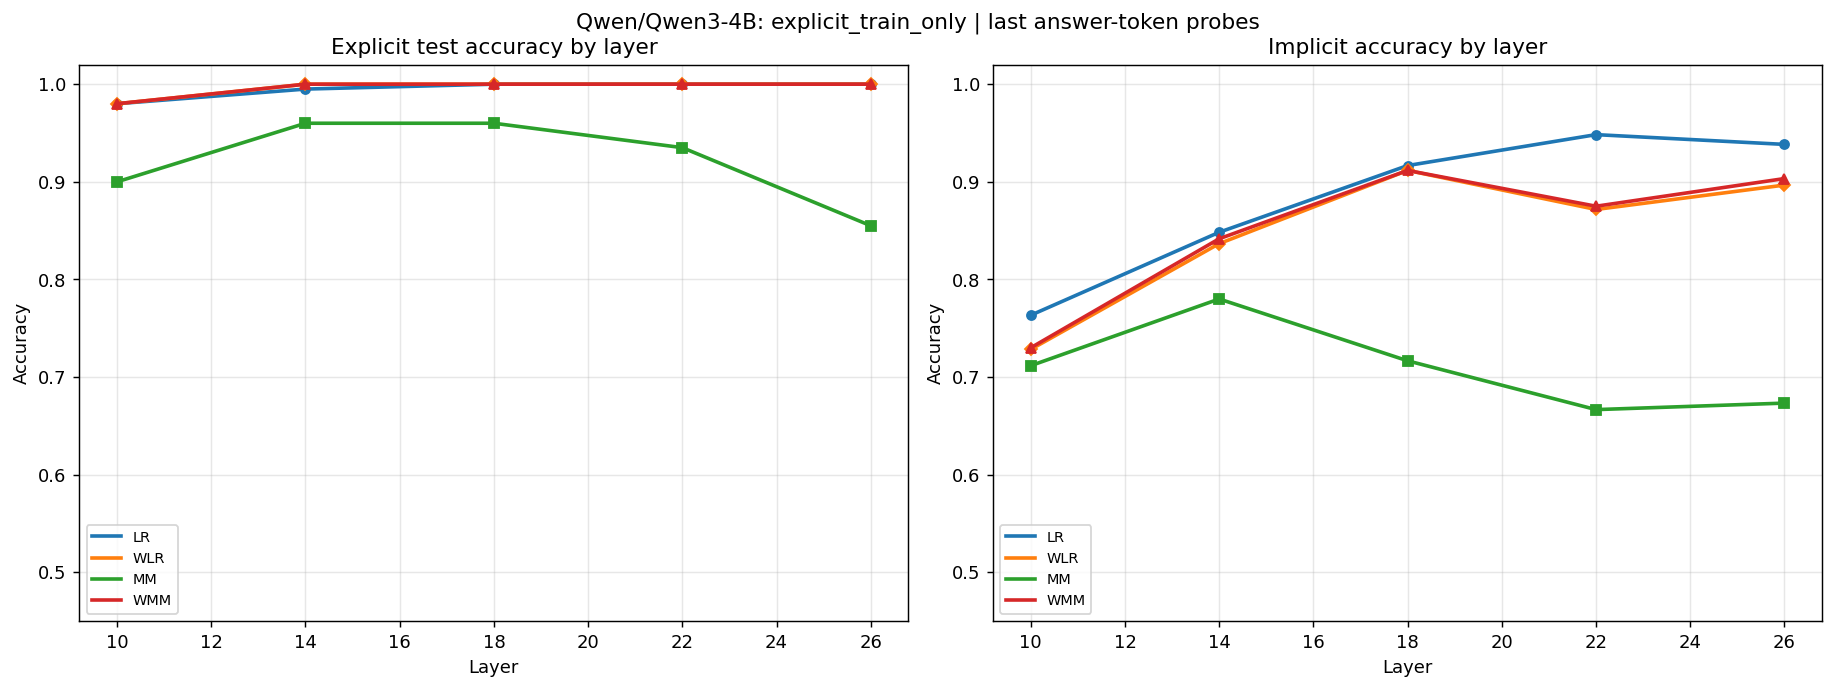

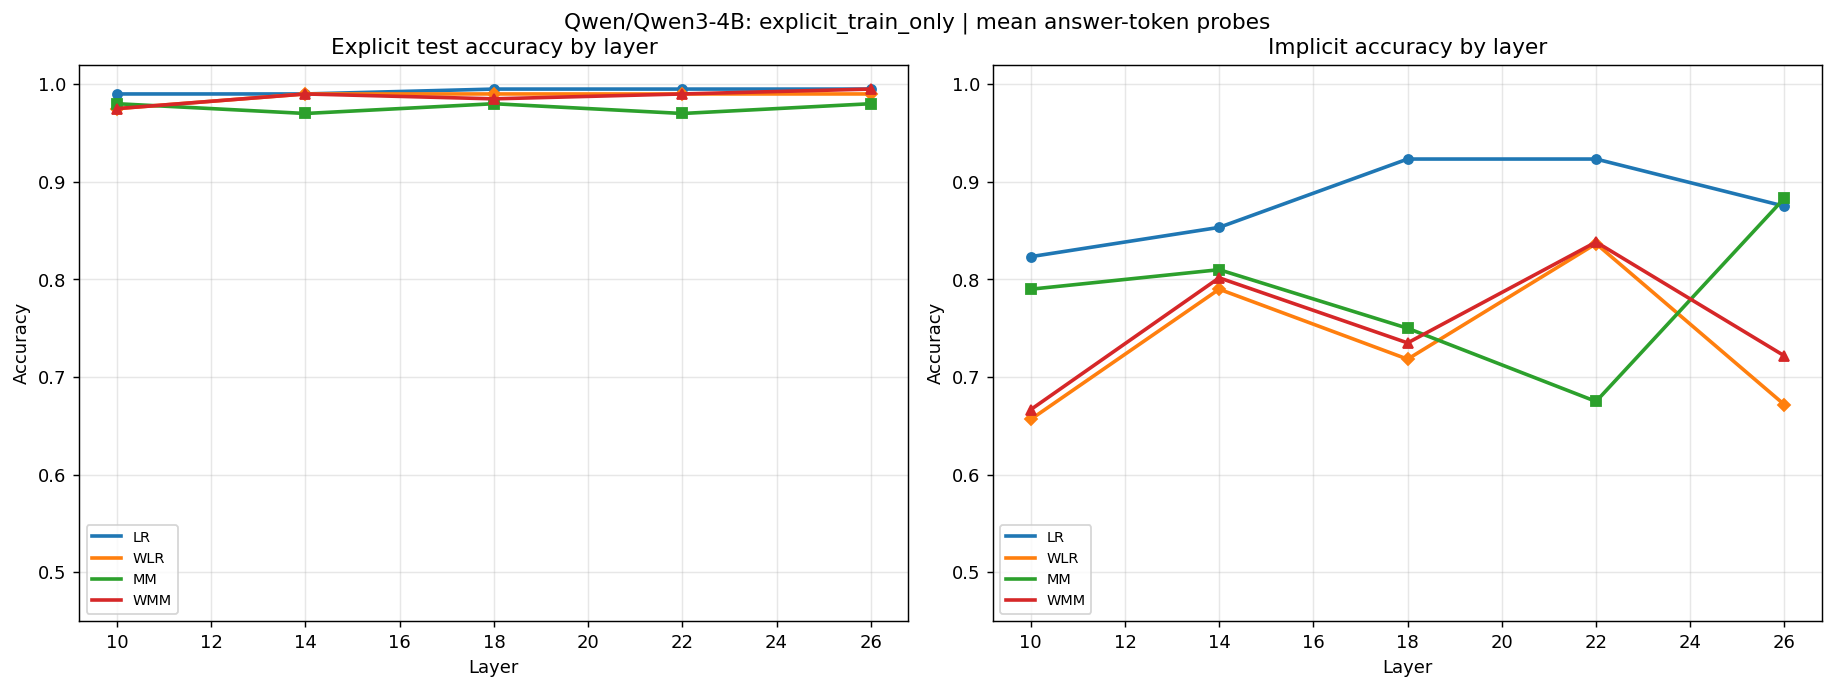

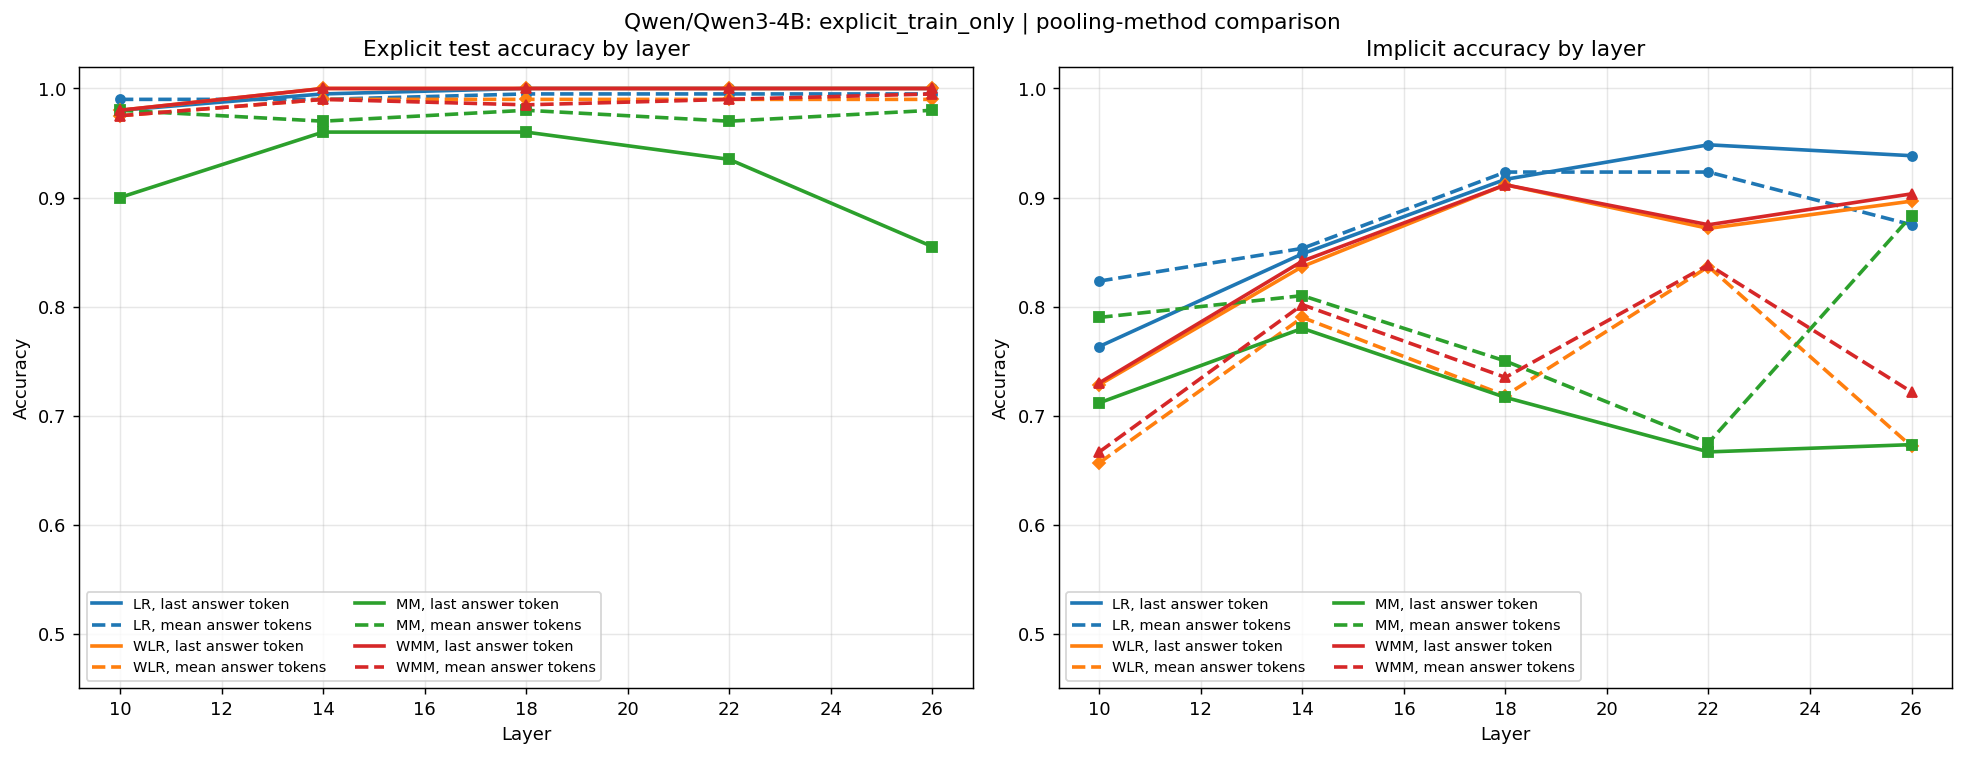

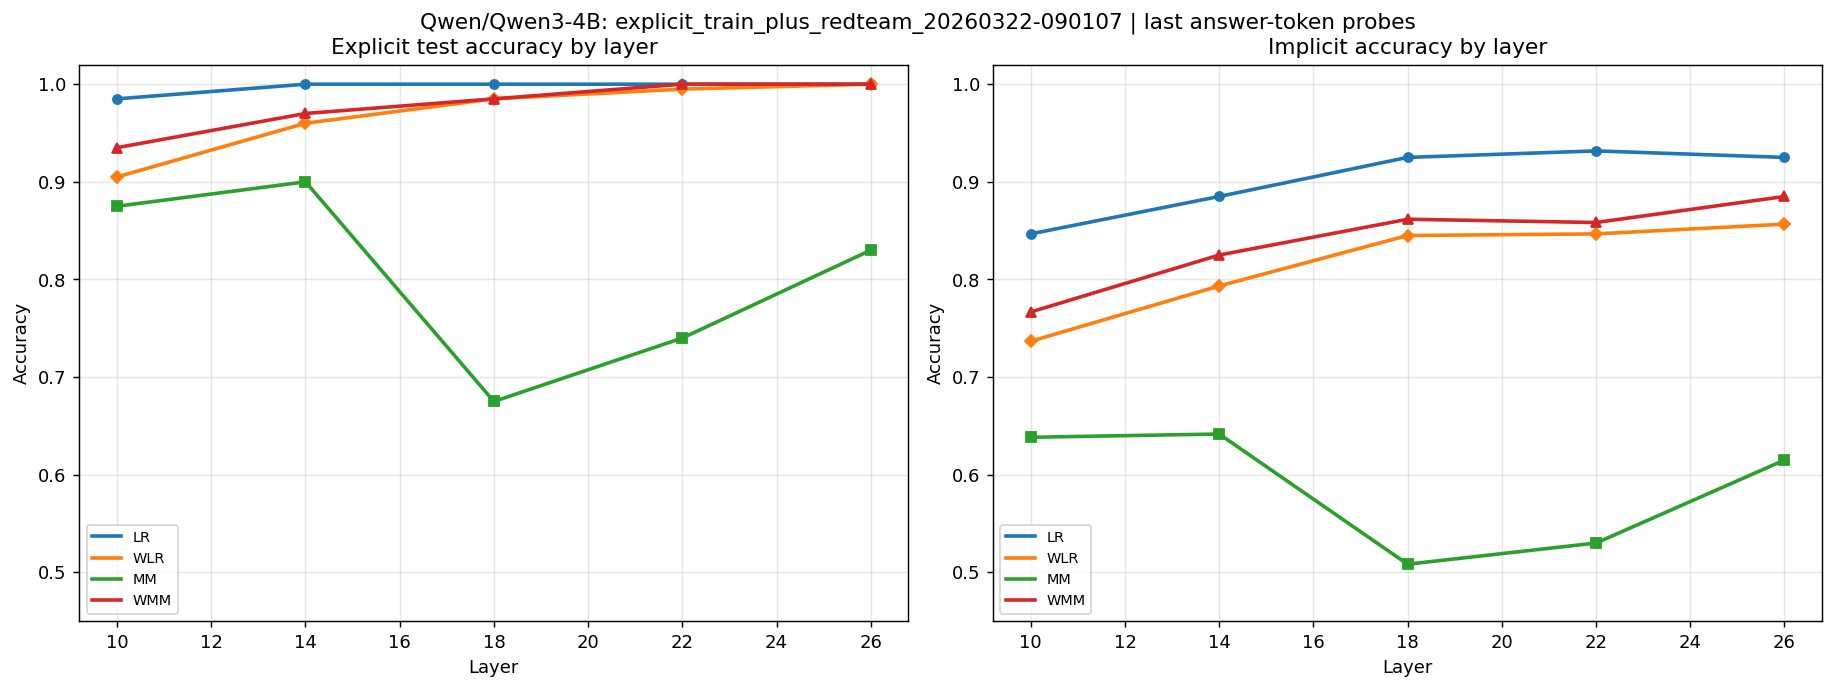

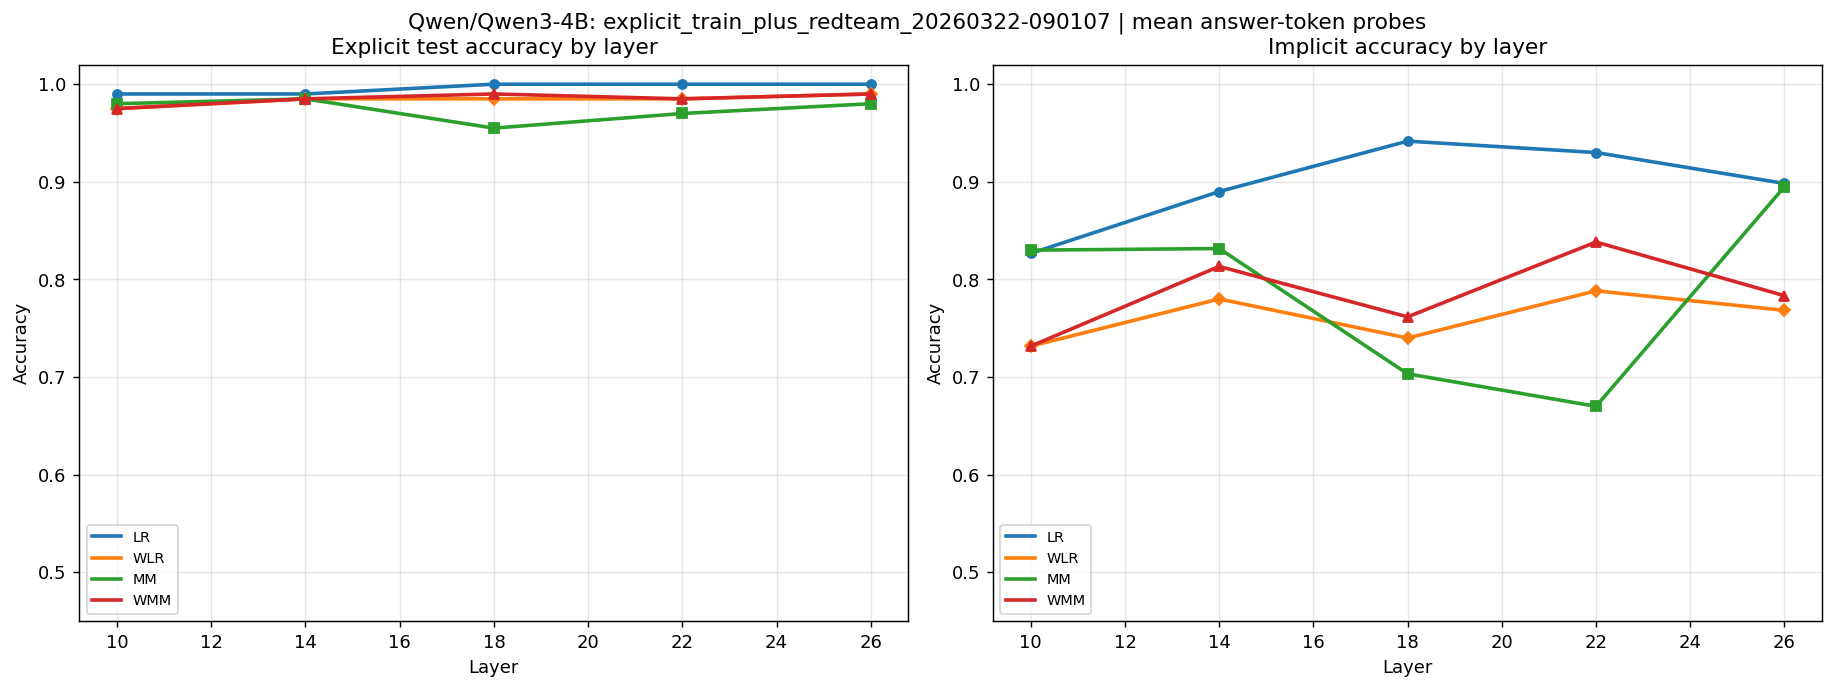

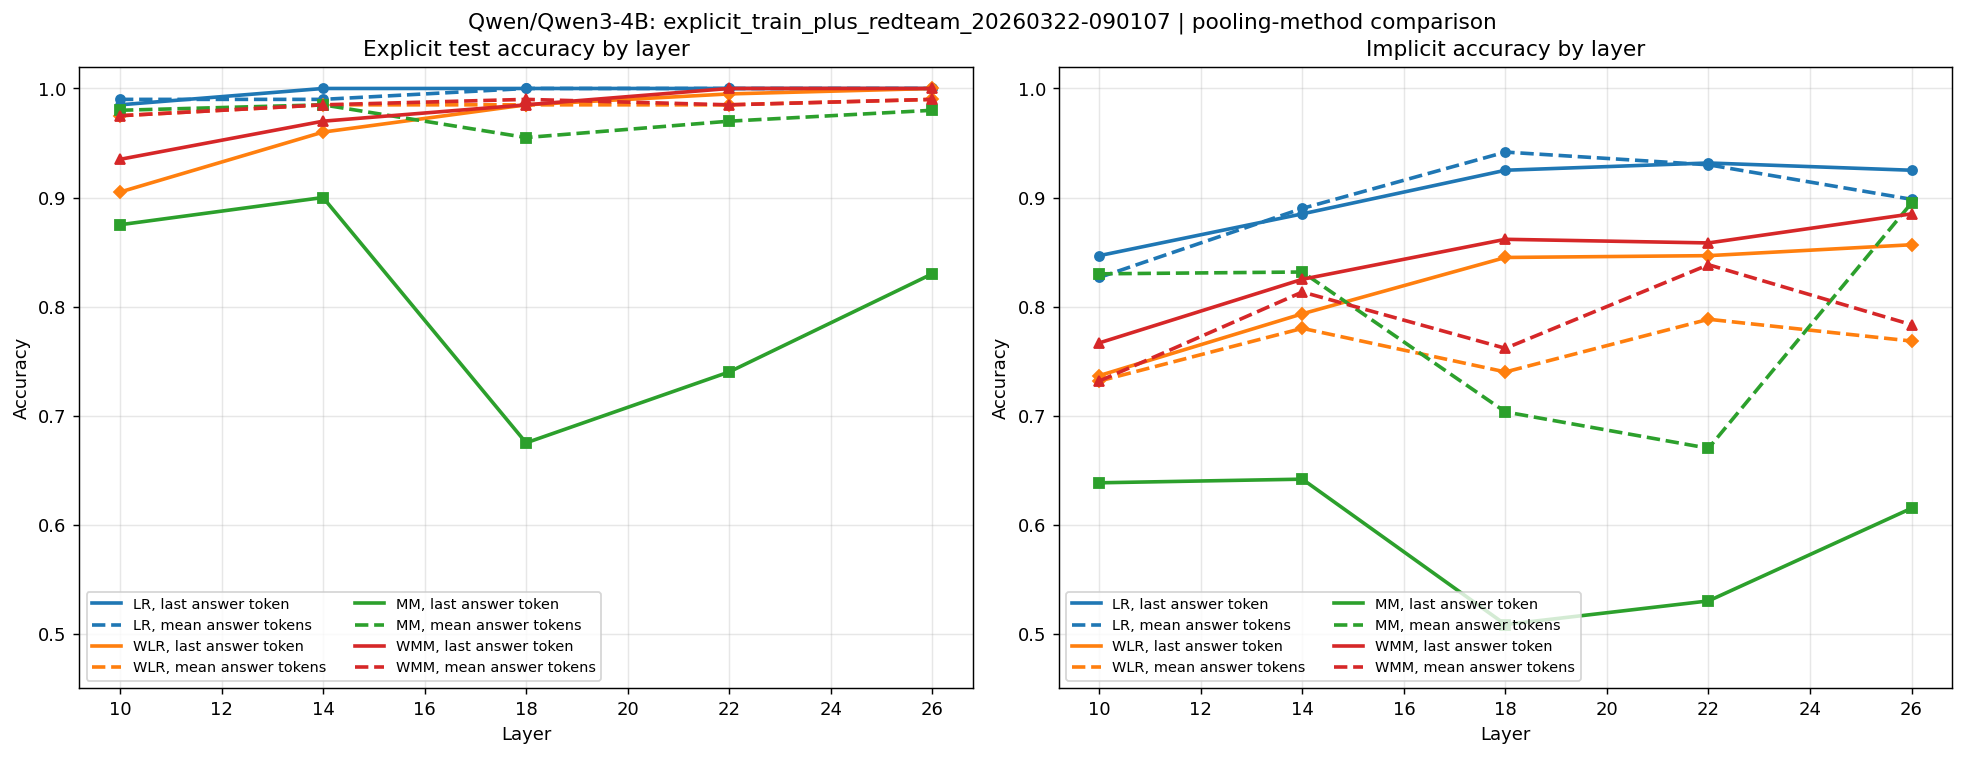

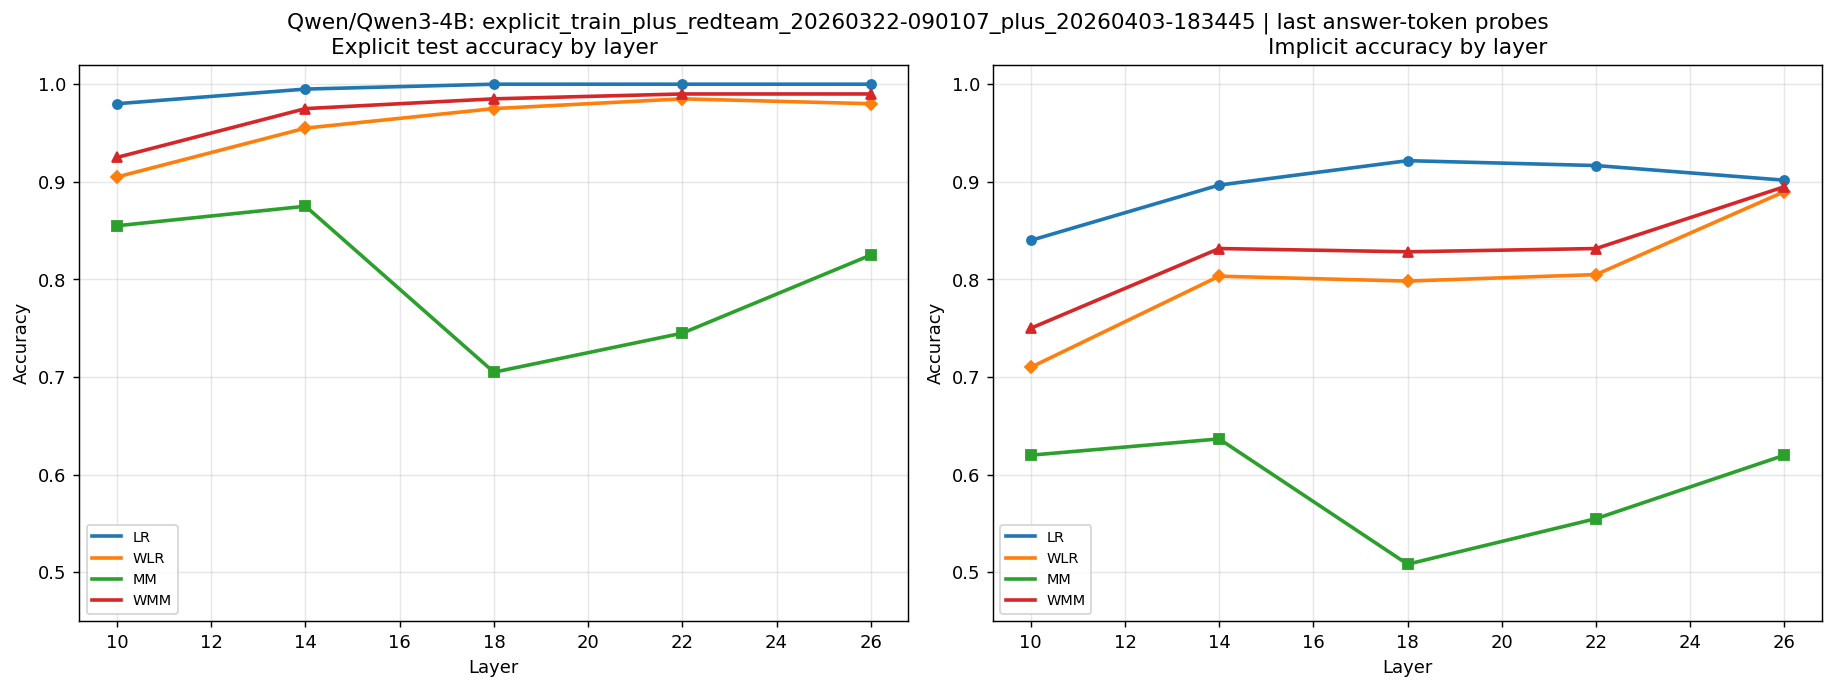

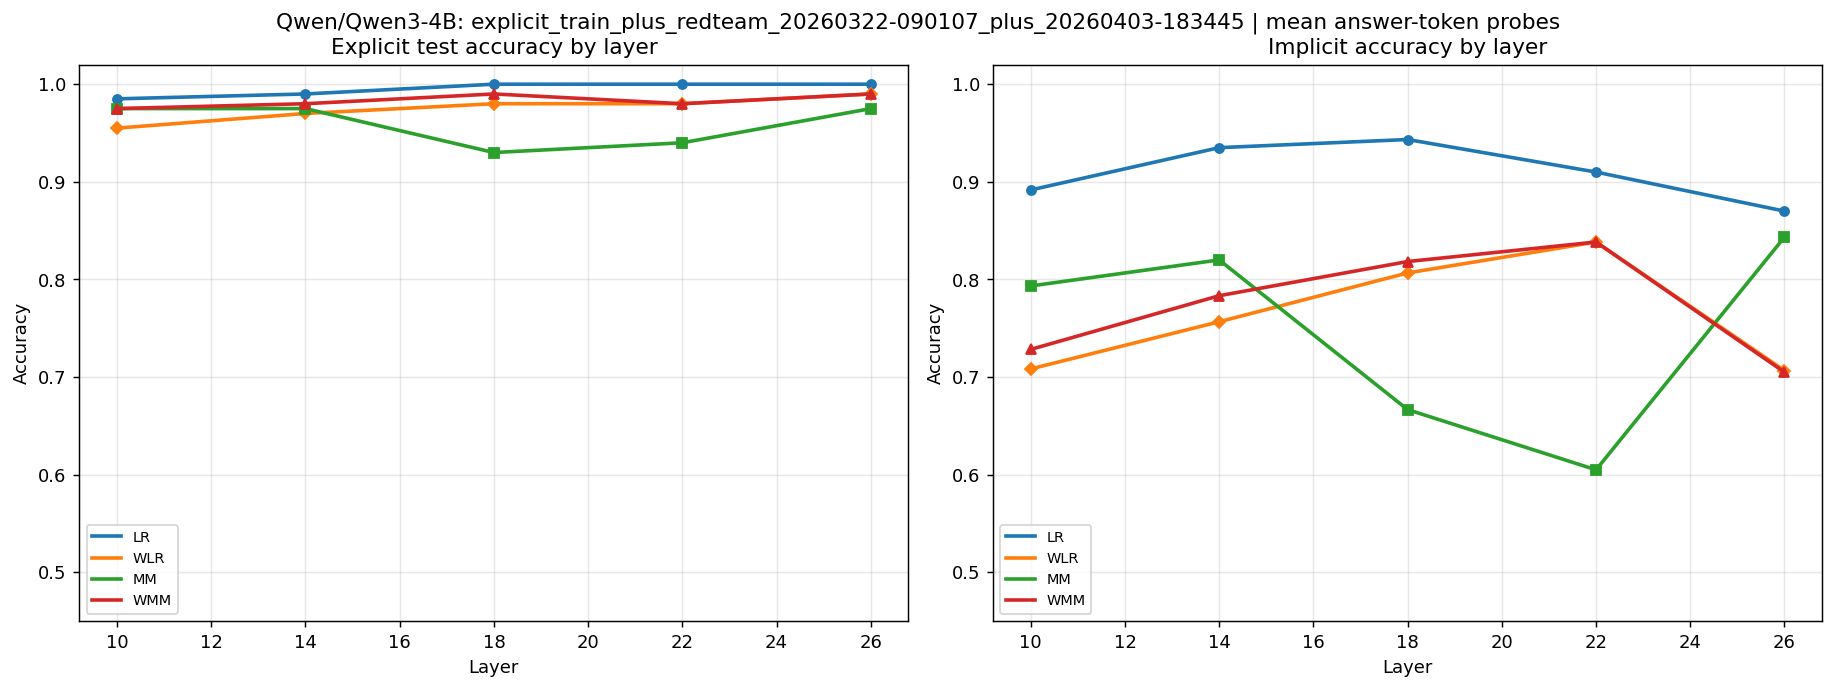

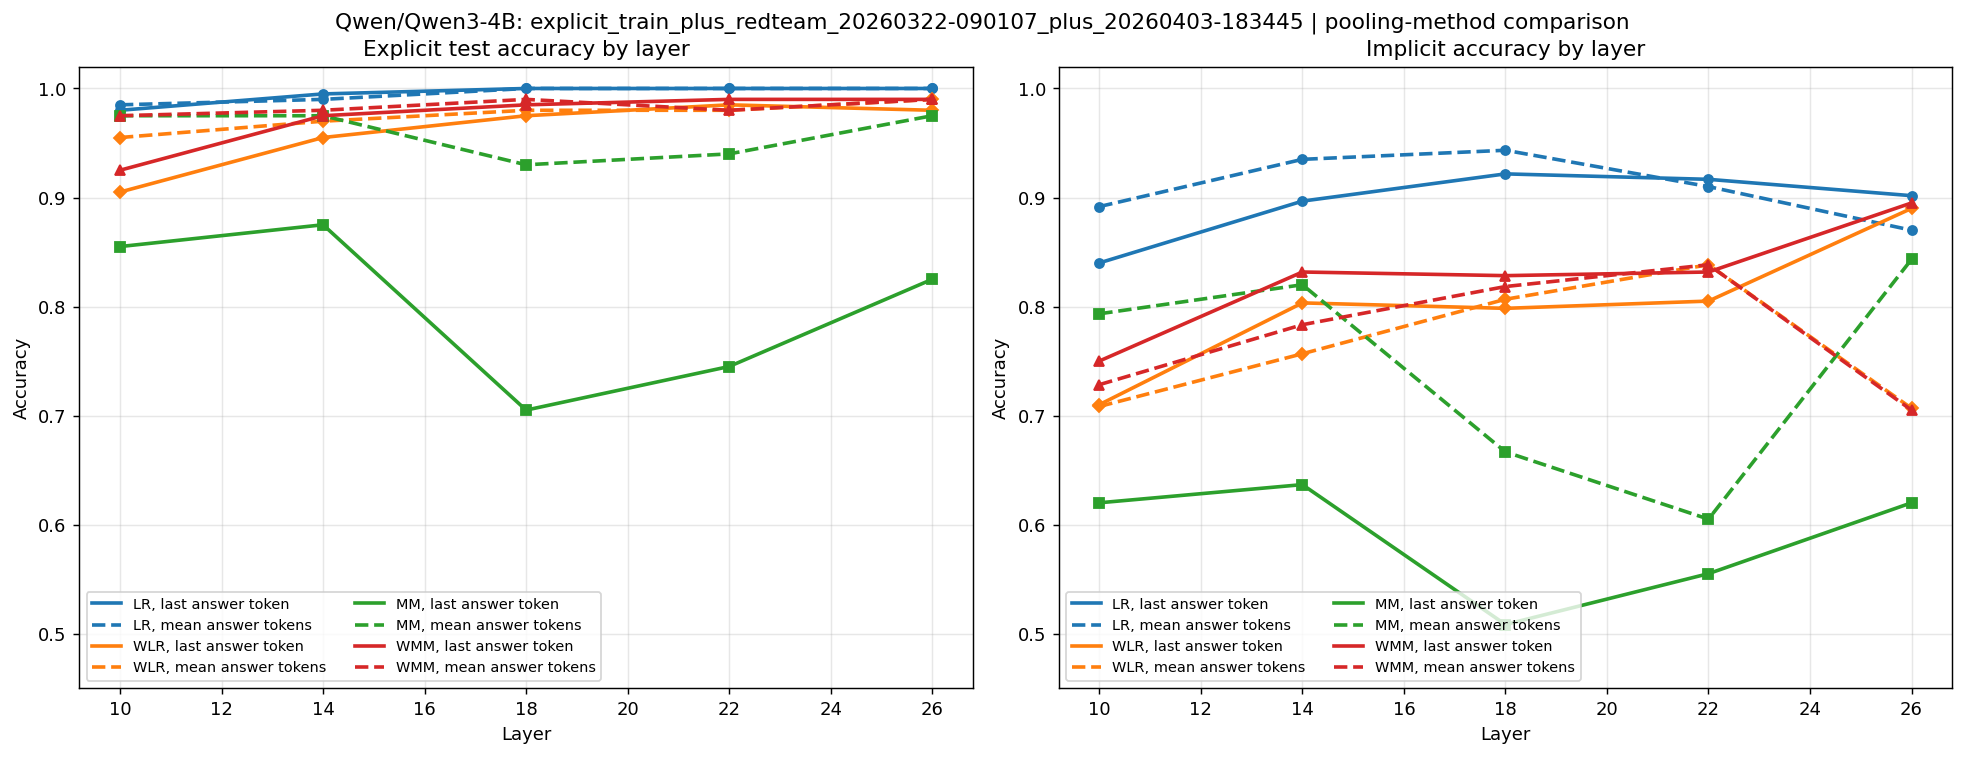

,train_dataset,figure_type,path
0,explicit_train_only,last_answer_token,/Users/michalmraz/code/spar-ai/temporal-awaren...
1,explicit_train_only,mean_answer_tokens,/Users/michalmraz/code/spar-ai/temporal-awaren...
2,explicit_train_only,comparison,/Users/michalmraz/code/spar-ai/temporal-awaren...
3,explicit_train_plus_redteam_20260322-090107,last_answer_token,/Users/michalmraz/code/spar-ai/temporal-awaren...
4,explicit_train_plus_redteam_20260322-090107,mean_answer_tokens,/Users/michalmraz/code/spar-ai/temporal-awaren...
5,explicit_train_plus_redteam_20260322-090107,comparison,/Users/michalmraz/code/spar-ai/temporal-awaren...
6,explicit_train_plus_redteam_20260322-090107_pl...,last_answer_token,/Users/michalmraz/code/spar-ai/temporal-awaren...
7,explicit_train_plus_redteam_20260322-090107_pl...,mean_answer_tokens,/Users/michalmraz/code/spar-ai/temporal-awaren...
8,explicit_train_plus_redteam_20260322-090107_pl...,comparison,/Users/michalmraz/code/spar-ai/temporal-awaren...


In [3]:
REPLOT_DIR = RUN_DIR / 'replots_from_notebook'
REPLOT_DIR.mkdir(parents=True, exist_ok=True)

regime_results = {}
for train_dataset in metadata.get('train_regimes', metrics_df['train_dataset'].drop_duplicates().tolist()):
    regime_results[train_dataset] = {}
    for feature_name in metadata.get('feature_names', metrics_df['feature_name'].drop_duplicates().tolist()):
        subset = (
            metrics_df[
                (metrics_df['train_dataset'] == train_dataset)
                & (metrics_df['feature_name'] == feature_name)
            ]
            .sort_values('layer')
            .reset_index(drop=True)
        )
        if len(subset):
            regime_results[train_dataset][feature_name] = subset

replot_rows = []
for regime_name, feature_map in regime_results.items():
    if 'last_answer_token' not in feature_map or 'mean_answer_tokens' not in feature_map:
        continue
    safe_regime_name = regime_name.replace('/', '_')
    last_df = feature_map['last_answer_token']
    mean_df = feature_map['mean_answer_tokens']

    last_fig = draw_pooling_only_figure(last_df, f"{metadata['model_name']}: {regime_name} | last answer-token probes", STYLE_LAST_ONLY)
    mean_fig = draw_pooling_only_figure(mean_df, f"{metadata['model_name']}: {regime_name} | mean answer-token probes", STYLE_MEAN_ONLY)
    comparison_fig = draw_comparison_figure(last_df, mean_df, f"{metadata['model_name']}: {regime_name} | pooling-method comparison")

    last_fig_path = REPLOT_DIR / f'{safe_regime_name}_last_answer_token_replot.png'
    mean_fig_path = REPLOT_DIR / f'{safe_regime_name}_mean_answer_tokens_replot.png'
    comparison_fig_path = REPLOT_DIR / f'{safe_regime_name}_comparison_replot.png'

    last_fig.savefig(last_fig_path, dpi=200, bbox_inches='tight')
    mean_fig.savefig(mean_fig_path, dpi=200, bbox_inches='tight')
    comparison_fig.savefig(comparison_fig_path, dpi=200, bbox_inches='tight')

    display(last_fig)
    display(mean_fig)
    display(comparison_fig)
    plt.close(last_fig)
    plt.close(mean_fig)
    plt.close(comparison_fig)

    replot_rows.extend([
        {'train_dataset': regime_name, 'figure_type': 'last_answer_token', 'path': str(last_fig_path)},
        {'train_dataset': regime_name, 'figure_type': 'mean_answer_tokens', 'path': str(mean_fig_path)},
        {'train_dataset': regime_name, 'figure_type': 'comparison', 'path': str(comparison_fig_path)},
    ])

replot_df = pd.DataFrame(replot_rows)
display(replot_df)


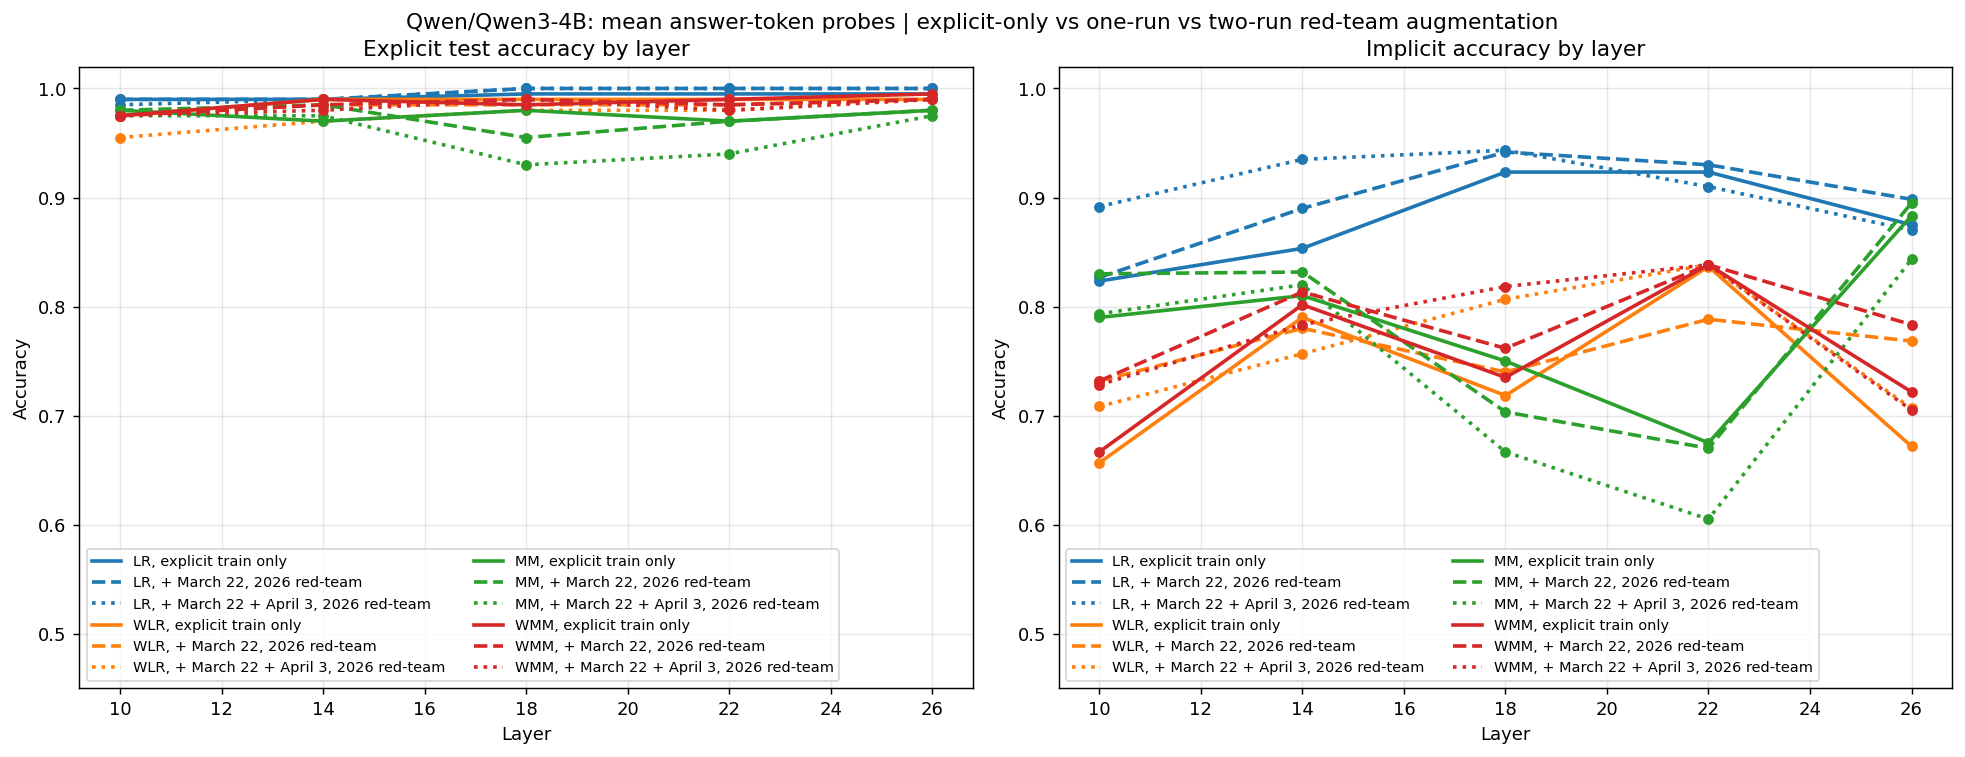

Saved replots in: /Users/michalmraz/code/spar-ai/temporal-awareness/results/qwen_question_options_answer_probe_variations_vast/20260405-185421/replots_from_notebook
Saved replot index: /Users/michalmraz/code/spar-ai/temporal-awareness/results/qwen_question_options_answer_probe_variations_vast/20260405-185421/replots_from_notebook/qwen3_4b_question_options_answer_probe_replots.csv


,train_dataset,figure_type,path
0,explicit_train_only,last_answer_token,/Users/michalmraz/code/spar-ai/temporal-awaren...
1,explicit_train_only,mean_answer_tokens,/Users/michalmraz/code/spar-ai/temporal-awaren...
2,explicit_train_only,comparison,/Users/michalmraz/code/spar-ai/temporal-awaren...
3,explicit_train_plus_redteam_20260322-090107,last_answer_token,/Users/michalmraz/code/spar-ai/temporal-awaren...
4,explicit_train_plus_redteam_20260322-090107,mean_answer_tokens,/Users/michalmraz/code/spar-ai/temporal-awaren...
5,explicit_train_plus_redteam_20260322-090107,comparison,/Users/michalmraz/code/spar-ai/temporal-awaren...
6,explicit_train_plus_redteam_20260322-090107_pl...,last_answer_token,/Users/michalmraz/code/spar-ai/temporal-awaren...
7,explicit_train_plus_redteam_20260322-090107_pl...,mean_answer_tokens,/Users/michalmraz/code/spar-ai/temporal-awaren...
8,explicit_train_plus_redteam_20260322-090107_pl...,comparison,/Users/michalmraz/code/spar-ai/temporal-awaren...
9,all,mean_training_comparison,/Users/michalmraz/code/spar-ai/temporal-awaren...


In [4]:
primary_run_id = metadata.get('primary_red_team_run_id')
two_run_slug = metadata.get('two_red_team_runs_slug')

explicit_only_name = 'explicit_train_only'
one_run_name = f'explicit_train_plus_redteam_{primary_run_id}' if primary_run_id else None
two_run_name = f'explicit_train_plus_redteam_{two_run_slug}' if two_run_slug else None

required_names = [explicit_only_name, one_run_name, two_run_name]
if all(name in regime_results and 'mean_answer_tokens' in regime_results[name] for name in required_names if name is not None):
    three_way_fig = draw_mean_training_comparison_three_way_figure(
        regime_results[explicit_only_name]['mean_answer_tokens'],
        regime_results[one_run_name]['mean_answer_tokens'],
        regime_results[two_run_name]['mean_answer_tokens'],
        f"{metadata['model_name']}: mean answer-token probes | explicit-only vs one-run vs two-run red-team augmentation",
    )
    three_way_fig_path = REPLOT_DIR / 'mean_training_comparison_replot.png'
    three_way_fig.savefig(three_way_fig_path, dpi=200, bbox_inches='tight')
    display(three_way_fig)
    plt.close(three_way_fig)
    replot_df = pd.concat([
        replot_df,
        pd.DataFrame([{'train_dataset': 'all', 'figure_type': 'mean_training_comparison', 'path': str(three_way_fig_path)}]),
    ], ignore_index=True)
else:
    print('Skipping three-way mean-training comparison because not all expected regimes were found.')

replot_index_path = REPLOT_DIR / 'qwen3_4b_question_options_answer_probe_replots.csv'
replot_df.to_csv(replot_index_path, index=False)

print('Saved replots in:', REPLOT_DIR)
print('Saved replot index:', replot_index_path)
display(replot_df)
